# NB_00 — Architecture Diagrams

This notebook renders Mermaid flowcharts for each of the six agentic RAG architectures evaluated in the thesis and saves them as SVG files for inclusion in the written report.

## Section overview

1. **Render all diagrams to SVG** — call `render_all()` for each architecture and the shared legend
2. **Display legend and all architectures** — render SVGs inline with titles and descriptions

## Architecture overview

| # | Pattern | Decision-making |
|---|---|---|
| 1 | Deterministic Pipeline | None — fixed 8-step sequence |
| 2 | Planner-Executor | LLM generates a tool-execution plan |
| 3 | Router-Specialist | LLM classifies intent, routes to specialist sub-graph |
| 4 | Blackboard / Swarm | Dispatcher inspects state, picks next agent each tick |
| 5 | Hierarchical Decomposition | LLM splits question, workers answer sub-parts |
| 6 | ReAct | LLM emits Thought + Action in a loop |

## Prerequisites

- `mmdc` (Mermaid CLI) must be on `PATH`: `npm install -g @mermaid-js/mermaid-cli`

Run cells from top to bottom.

In [13]:
import sys
from pathlib import Path

# Ensure project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [14]:
from IPython.display import SVG, Markdown, display

from sources.drawer import (
    DESCRIPTIONS,
    DIAGRAMS,
    TITLES,
    render_all,
)

## Step 1: Render all diagrams to SVG

Calls `render_all()` from `sources/drawer.py` for each of the six architecture diagrams and the shared legend. Output SVG files are written to `data/diagrams/`.

In [15]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "diagrams"

svg_paths = render_all(OUTPUT_DIR, theme="default", background="transparent")

print(f"Rendered {len(svg_paths)} diagrams to {OUTPUT_DIR}")
for name, path in svg_paths.items():
    print(f"  {name}: {path}")

Rendered 7 diagrams to /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams
  deterministic: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/deterministic.svg
  planner_executor: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/planner_executor.svg
  router_specialist: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/router_specialist.svg
  blackboard: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/blackboard.svg
  hierarchical: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/hierarchical.svg
  react: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/react.svg
  legend: /Users/mchojna/Documents/Repozytoria/master-thesis/code/data/diagrams/legend.svg


## Step 2: Display legend and all architectures

Loads the generated SVG files and renders them inline. The legend cell comes first, followed by one diagram per architecture in `ARCH_ORDER`, each with its title and description from `TITLES` and `DESCRIPTIONS`.

### Legend

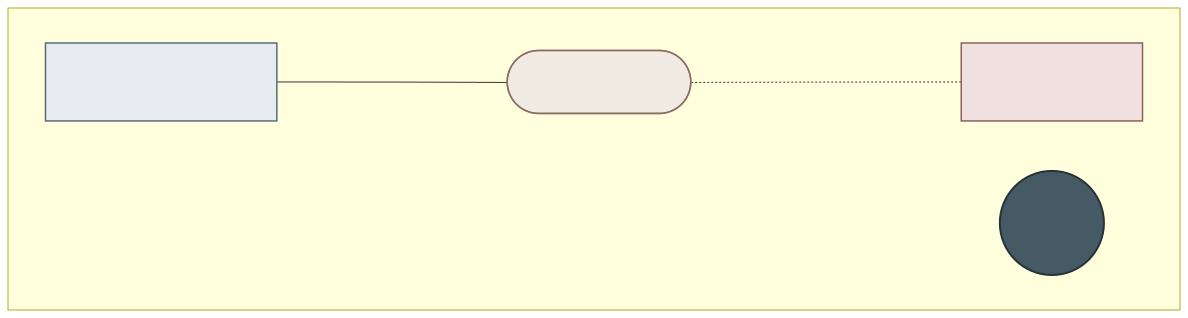

---
### Pattern 1 — Deterministic Pipeline

Fixed linear sequence with no LLM routing decisions. Every question passes through the same eight processing steps, including evidence selection before synthesis.

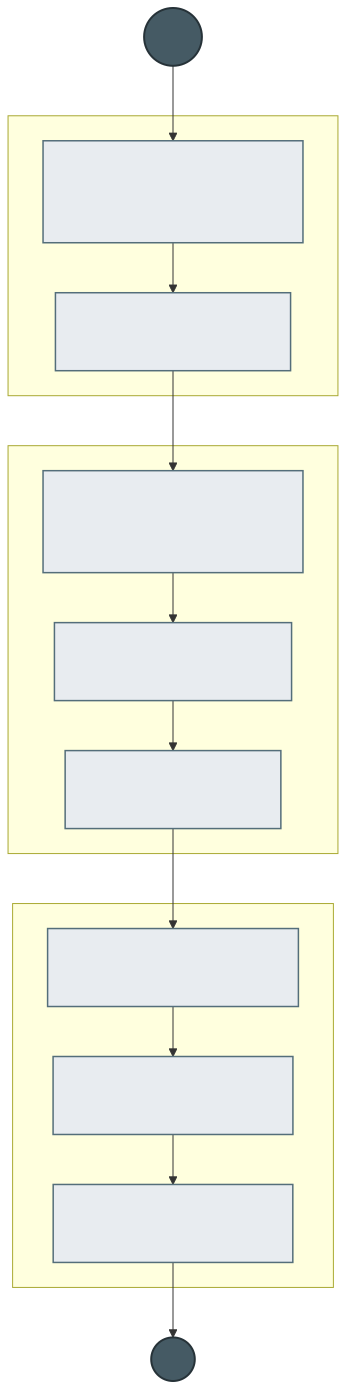

---
### Pattern 2 — Planner-Executor

An LLM planner decides tool execution order, then an executor loop runs each step sequentially until the plan is complete, followed by an evidence-selection and synthesis tail.

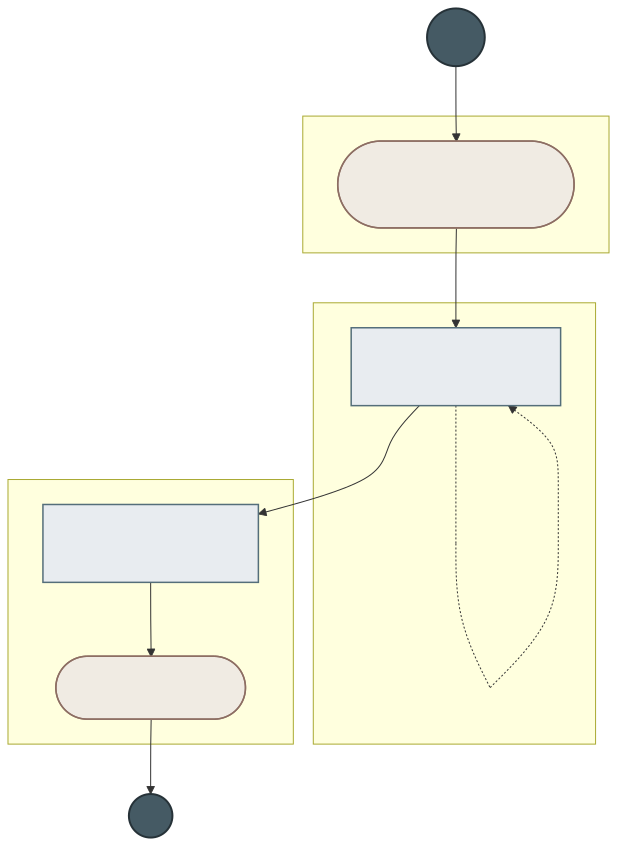

---
### Pattern 3 — Router-Specialist

An LLM router classifies the question intent, then dispatches to one of four specialist sub-graphs with tailored retrieval strategies and an evidence-selection step before answer generation.

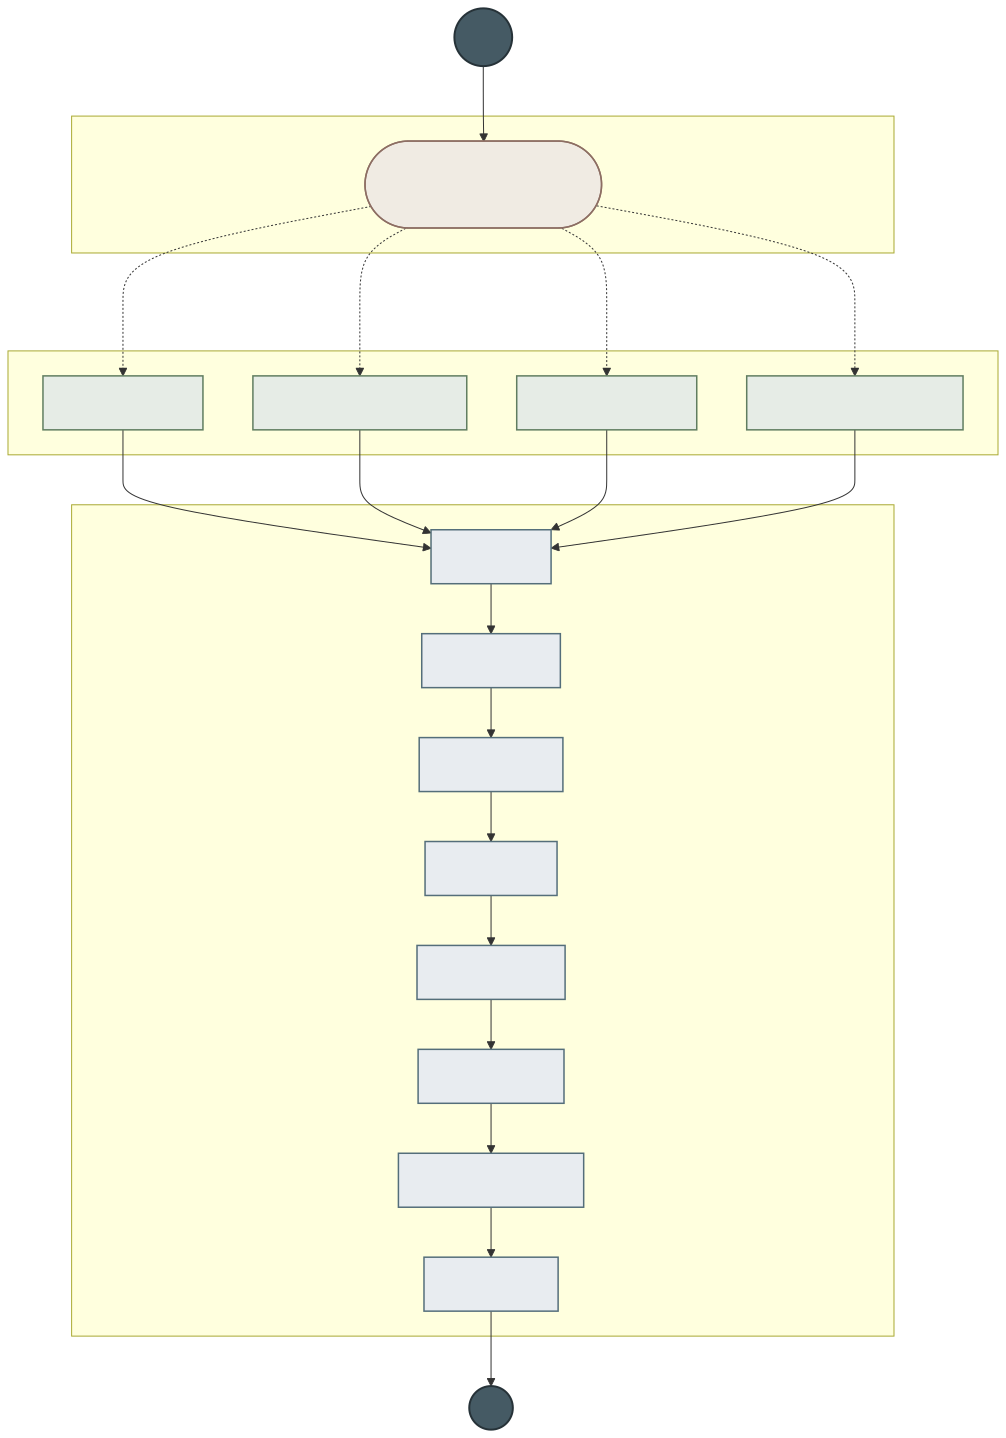

---
### Pattern 4 — Blackboard / Swarm

A central dispatcher inspects shared state each iteration and routes to the next agent, including an explicit evidence-selector agent before final answering. A max-iterations guard prevents infinite loops.

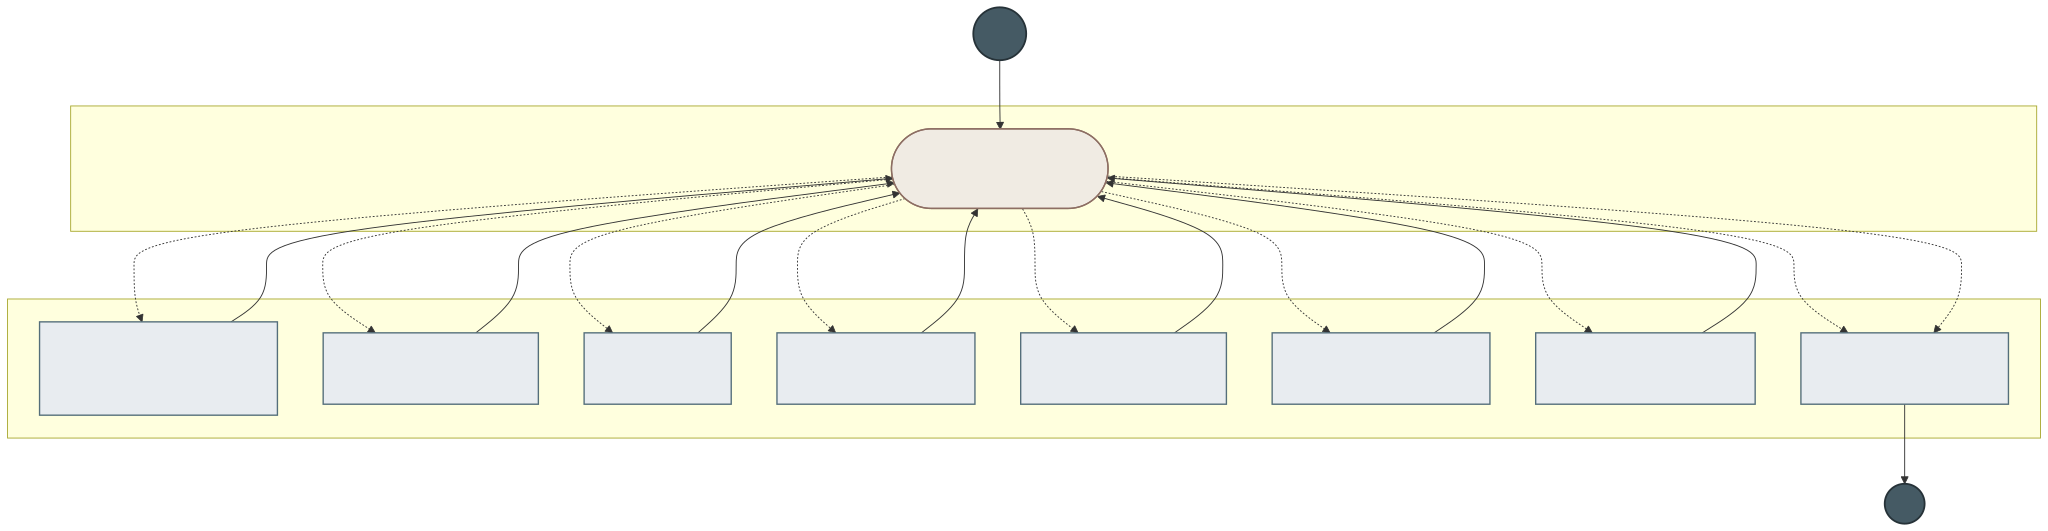

---
### Pattern 5 — Hierarchical Decomposition

A decomposer breaks the question into 1-3 sub-questions. Each is answered by a worker mini-pipeline. Evidence is compacted before a synthesizer merges partial answers.

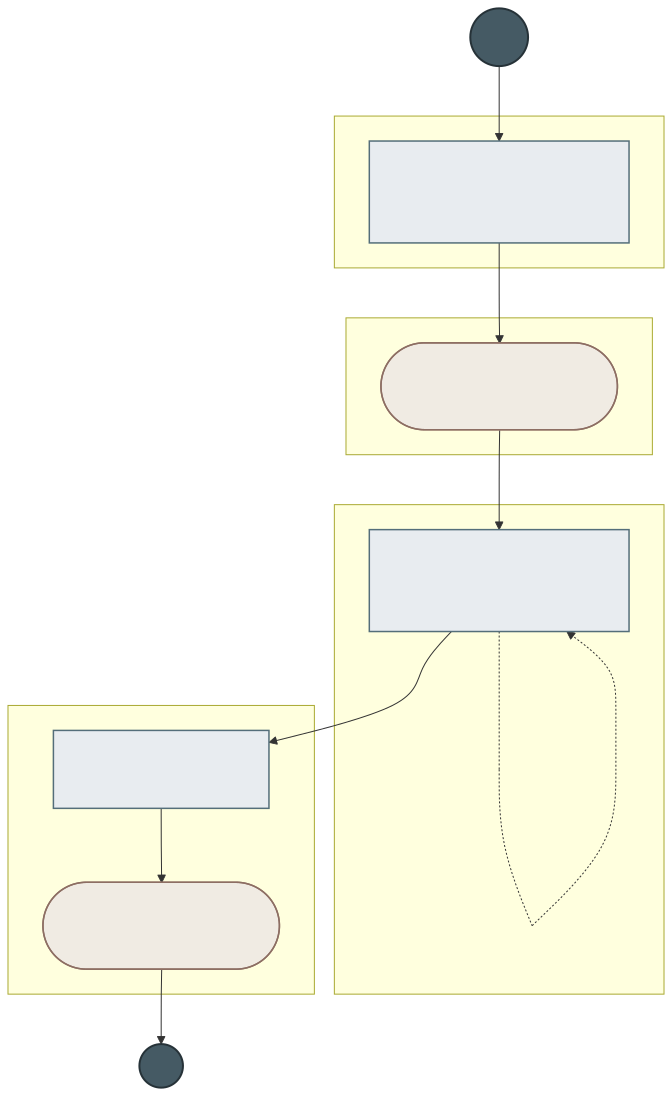

---
### Pattern 6 — ReAct

The agent produces a structured Thought + Action decision. A tool-executor dispatches the action, with evidence selection on finish and a guarded fallback on iteration cap.

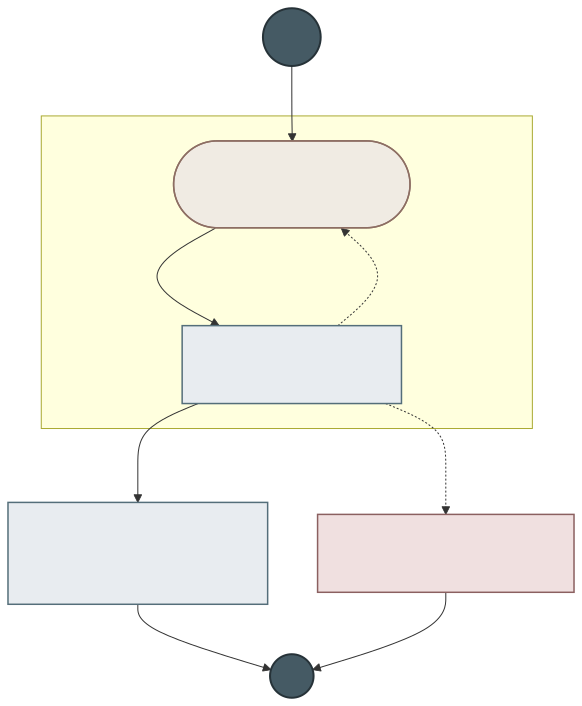

In [16]:
# Display the legend first
display(Markdown("### Legend"))
display(SVG(filename=str(svg_paths["legend"])))

# Display each architecture diagram
ARCHITECTURE_NAMES = [k for k in DIAGRAMS if k != "legend"]

for name in ARCHITECTURE_NAMES:
    title = TITLES[name]
    desc = DESCRIPTIONS[name]
    svg_path = svg_paths[name]

    display(Markdown(f"---\n### {title}\n\n{desc}"))
    display(SVG(filename=str(svg_path)))